# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [3]:
import os

# 1. Ruta de la data y listas
carpeta_libros = os.path.abspath("..\\data\\1000Libros")
textos_gutenberg = []
nombres_archivos = []

# 2. Cargar hasta 1000 libros
archivos = os.listdir(carpeta_libros)[:1000]
for archivo in archivos:
    try:
        with open(os.path.join(carpeta_libros, archivo), "r", encoding="utf-8") as f:
            textos_gutenberg.append(f.read())
            nombres_archivos.append(archivo)
    except:
        continue

print(f"Corpus cargado: {len(textos_gutenberg)} libros.")

Corpus cargado: 1000 libros.


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import numpy as np
import time

# Capturamos el momento exacto en que empieza todo el proceso
tiempo_inicio_total = time.time()

# --- ACTIVIDAD 1: Construir la matriz de términos (TF) y calcular el DF ---

# Definimos filtros manuales para que palabras comunes como "de" o "la" no ensucien el conteo.
mis_filtros = ['de', 'la', 'el', 'en', 'y', 'que', 'los', 'un', 'una', 'con', 'del', 'al']

# 'vectorizador_conteo' crea la matriz TF.
# Limitamos a 1000 palabras para ver solo las más representativas.
vectorizador_conteo = CountVectorizer(stop_words=mis_filtros, max_features=1000)
matriz_tf = vectorizador_conteo.fit_transform(textos_gutenberg)

# Calculamos el (DF).
# (matriz_tf > 0) marca con True donde hay una palabra; luego sumamos por columna para saber en cuántos libros sale.
df_valores = np.array((matriz_tf > 0).sum(axis=0)).flatten()


# --- ACTIVIDAD 2: Calcular TF-IDF utilizando sklearn ---

# El TfidfVectorizer calcula la frecuencia (TF) y la rareza (IDF) al mismo tiempo.
# El resultado es una matriz donde cada palabra tiene un "peso" o importancia matemática.
vectorizador_tfidf = TfidfVectorizer(stop_words=mis_filtros, max_features=1000)
matriz_tfidf = vectorizador_tfidf.fit_transform(textos_gutenberg)


# --- ACTIVIDAD 3: Visualizar los valores en un DataFrame para analizar diferencias ---

# Extraemos los nombres de las 1000 palabras para que la tabla sea legible.
palabras = vectorizador_tfidf.get_feature_names_out()

# Creamos la tabla (DataFrame) para comparar visualmente.
df_analisis = pd.DataFrame({
    'Palabra': palabras,
    'DF (Frecuencia)': df_valores,
    'IDF (Rareza)': vectorizador_tfidf.idf_  # El valor IDF mide qué tan especial es el término.
})

# Ordenamos por la "Rareza" (IDF) de mayor a menor.
# Las palabras arriba de la lista son las más útiles para distinguir un libro de otro.
print("\nTop 10 palabras por Rareza (IDF):")
print(df_analisis.sort_values(by='IDF (Rareza)', ascending=False).head(10))

# Capturamos el final y calculamos la diferencia total
tiempo_fin_total = time.time()
print(f"\nTIEMPO TOTAL DE EJECUCIÓN: {tiempo_fin_total - tiempo_inicio_total:.4f} segundos")


Top 10 palabras por Rareza (IDF):
    Palabra  DF (Frecuencia)  IDF (Rareza)
928      ug                3      6.416100
552      mg                5      6.010635
601      ng                8      5.605170
54      ang               15      5.029806
10       _f               59      3.708050
258    dixo               72      3.511935
12       _m               74      3.484907
896    that               86      3.336487
466      it               87      3.325058
752    qual               87      3.325058

TIEMPO TOTAL DE EJECUCIÓN: 105.6968 segundos


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import time

# Iniciamos el cronómetro para medir la búsqueda
inicio_busqueda = time.time()

# Definimos la consulta en español ya que nuestro corpus está en ese idioma
consulta = "historia de caballeros y castillos" 

# 1. Transformación de la consulta:
# Convertimos el texto de búsqueda en un vector usando el mismo vocabulario de los libros.
vector_consulta = vectorizador_tfidf.transform([consulta])

# 2. Cálculo de Similitud Coseno:
# Comparamos matemáticamente el ángulo del vector consulta contra los 1000 vectores de los libros.
# Un valor cercano a 1 significa que el libro es muy relevante para la búsqueda.
puntajes_tfidf = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

# 3. Generación del Ranking:
# Creamos una tabla con los nombres de los archivos y su puntaje de relevancia.
# Ordenamos de mayor a menor para que los libros más importantes aparezcan primero.
ranking_tfidf = pd.DataFrame({
    'Libro': nombres_archivos,
    'Score_TFIDF': puntajes_tfidf
}).sort_values(by='Score_TFIDF', ascending=False)

# Mostramos los 5 resultados con mayor puntaje
print("Top 5 - Ranking TF-IDF:")
print(ranking_tfidf.head(5))

# Finalizamos el cronómetro
fin_busqueda = time.time()
print(f"\nTiempo de búsqueda y ranking: {fin_busqueda - inicio_busqueda:.4f} segundos")

Top 5 - Ranking TF-IDF:
                                                 Libro  Score_TFIDF
376              Guerras civiles de Granada Tomo I.txt     0.155312
596                Libros de caballerías Selección.txt     0.075542
116    Crónica de la conquista de Granada (1 de 2).txt     0.065947
241  El doncel de don Enrique el doliente, Tomo II ...     0.055542
117    Crónica de la conquista de Granada (2 de 2).txt     0.052391

Tiempo de búsqueda y ranking: 0.0344 segundos


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [11]:
from rank_bm25 import BM25Okapi
import time

# Iniciamos el cronómetro para medir el proceso de BM25
inicio_bm25 = time.time()

# --- PASO 1: Tokenización ---
# BM25 no acepta texto plano, dividimos cada libro en una lista de palabras en minúsculas.
textos_tokenizados = [doc.lower().split() for doc in textos_gutenberg]
consulta_tokenizada = consulta.lower().split()

# --- PASOS 2 al 6: Inicializar BM25 ---
# Al instanciar BM25Okapi, la librería realiza internamente los pasos del 2 al 6.
# los parámetros por defecto son (k1=1.5, b=0.75)
bm25 = BM25Okapi(textos_tokenizados)

# --- PASO 7: Función para calcular el score para todos los documentos ---
# Calculamos la probabilidad de relevancia de cada libro basándonos en la query tokenizada.
puntajes_bm25 = bm25.get_scores(consulta_tokenizada)

# --- PASO 8: Recuperar los documentos mejor puntuados (Ranking) ---
# Creamos un DataFrame para organizar los resultados y ordenamos de mayor a menor score.
ranking_bm25 = pd.DataFrame({
    'Libro': nombres_archivos,
    'Score_BM25': puntajes_bm25
}).sort_values(by='Score_BM25', ascending=False)

# Mostramos los 5 resultados con mayor probabilidad de relevancia
print("Top 5 - Ranking BM25:")
print(ranking_bm25.head(5))

# Finalizamos el cronómetro
fin_bm25 = time.time()
print(f"\nTiempo total ejecución BM25: {fin_bm25 - inicio_bm25:.4f} segundos")

Top 5 - Ranking BM25:
                                                 Libro  Score_BM25
116    Crónica de la conquista de Granada (1 de 2).txt   15.950512
337  Estudio descriptivo de los monumentos árabes d...   15.938178
440                   La alhambra; leyendas árabes.txt   15.932741
394  Historia de la literatura y del arte dramático...   15.831137
371  Granada, Poema Oriental, precedido de la Leyen...   15.777517

Tiempo total ejecución BM25: 421.8194 segundos


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

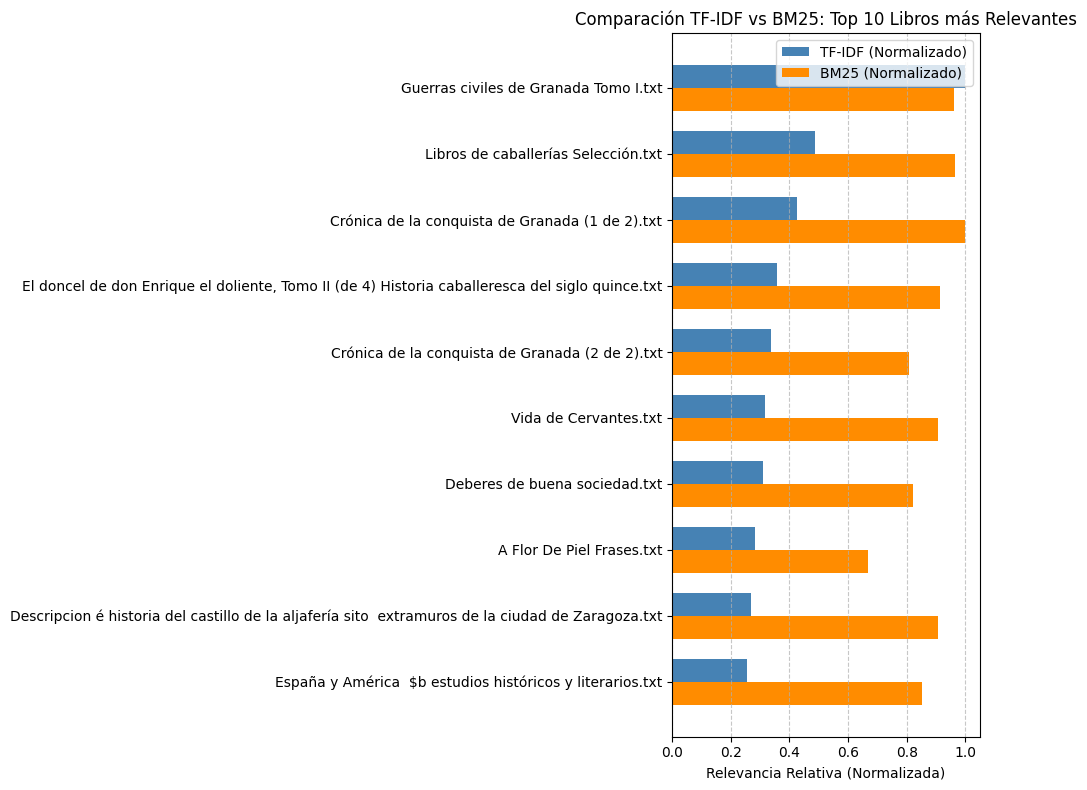

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Preparación de datos (Igual que antes) ---
comparacion = ranking_tfidf.merge(ranking_bm25, on='Libro').head(10)

# Normalización
score_tfidf_norm = comparacion['Score_TFIDF'] / comparacion['Score_TFIDF'].max()
score_bm25_norm = comparacion['Score_BM25'] / comparacion['Score_BM25'].max()

# --- 2. Gráfico Horizontal ya que es mucho más legible ---
fig, ax = plt.subplots(figsize=(10, 8)) # Ajustamos el alto para los 10 libros
y = np.arange(len(comparacion))
ancho = 0.35

# Invertimos el orden para que el mejor libro salga arriba
y = y[::-1] 

# Usamos barh para que se vea el gráfico horizontal en vez de vertical.
ax.barh(y + ancho/2, score_tfidf_norm, ancho, label='TF-IDF (Normalizado)', color='steelblue')
ax.barh(y - ancho/2, score_bm25_norm, ancho, label='BM25 (Normalizado)', color='darkorange')


ax.set_xlabel('Relevancia Relativa (Normalizada)')
ax.set_title('Comparación TF-IDF vs BM25: Top 10 Libros más Relevantes')
ax.set_yticks(y)
ax.set_yticklabels(comparacion['Libro']) # Ya no hace falta rotar el texto
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.7) # Guía visual para los puntajes

plt.tight_layout()
plt.show()

### 3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?

Al revisar mi gráfica, me di cuenta de un par de cosas interesantes sobre cómo se mueven los libros en el ranking:

    Noté que los libros que salen muy altos en TF-IDF aquí suelen ser los más extensos (como los tomos de las Guerras civiles de Granada). Esto pasa porque el TF-IDF es muy sensible a la repetición; si el libro es enorme y menciona muchas veces las palabras de mi búsqueda, el score sube casi por inercia.

    Hubo otros documentos, como los de Caballerías Selección, que aunque no eran los primeros en TF-IDF, en BM25 sacaron un puntaje proporcionalmente más alto. Son libros que parecen ser más específicos y no tan largos, lo que hace que el algoritmo los premie por ser "directos al punto".

### 4. ¿A qué se podría deber esta diferencia?

Creo que la diferencia principal está en la "inteligencia" matemática de cada modelo para manejar el ruido de los libros:

    En clase vimos que el TF-IDF es lineal, entre más veces salga la palabra, más puntos da. En cambio, BM25 tiene un tope. Entiende que si la palabra "caballero" ya salió 10 veces, que salga una vez más no aporta mucha relevancia extra.

    El TF-IDF no sabe si un libro tiene 10 o 500 páginas, solo cuenta términos. BM25 usa el promedio de longitud de todos los libros. Si un libro es corto pero tiene mis palabras clave, BM25 asume que es más probable que el libro trate específicamente de eso, mientras que en un libro largo podrían aparecer solo por relleno.

    Básicamente, TF-IDF se deja impresionar por el volumen de palabras, mientras que BM25 intenta calcular la probabilidad real de que el contenido me sirva.